# SE Scheduling Comparison: perpendicular vs swapped

| Scheduling | Tick 2 | Tick 3 | Hook error effect |
|---|---|---|---|
| `perpendicular` | X→NW, Z→SE | X→SE, Z→NW | hook chains run **perpendicular** to logical — FT |
| `swapped` | X→SE, Z→NW | X→NW, Z→SE | hook chains run **parallel** to logical — non-FT |

Using Z and X memory experiments: the swapped scheduling should hurt both independently.

In [1]:
import sys, os, io, contextlib
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import stim
from experiments.memory import MemoryExperiment
from src.ir.qec_system import QECSystem
from src.qec_code.surface_code.rotated import RotatedSurfaceCode, RotatedSurfaceCodeExtractionBlock
from src.noise.config import NoiseConfig
from src.simulation.decoder_backend import SimulationPipeline, ExperimentTask, DecoderConfig

## 1. Circuit diagram — d=3, Z memory, rounds=3

perpendicular: 24 det, 1 obs


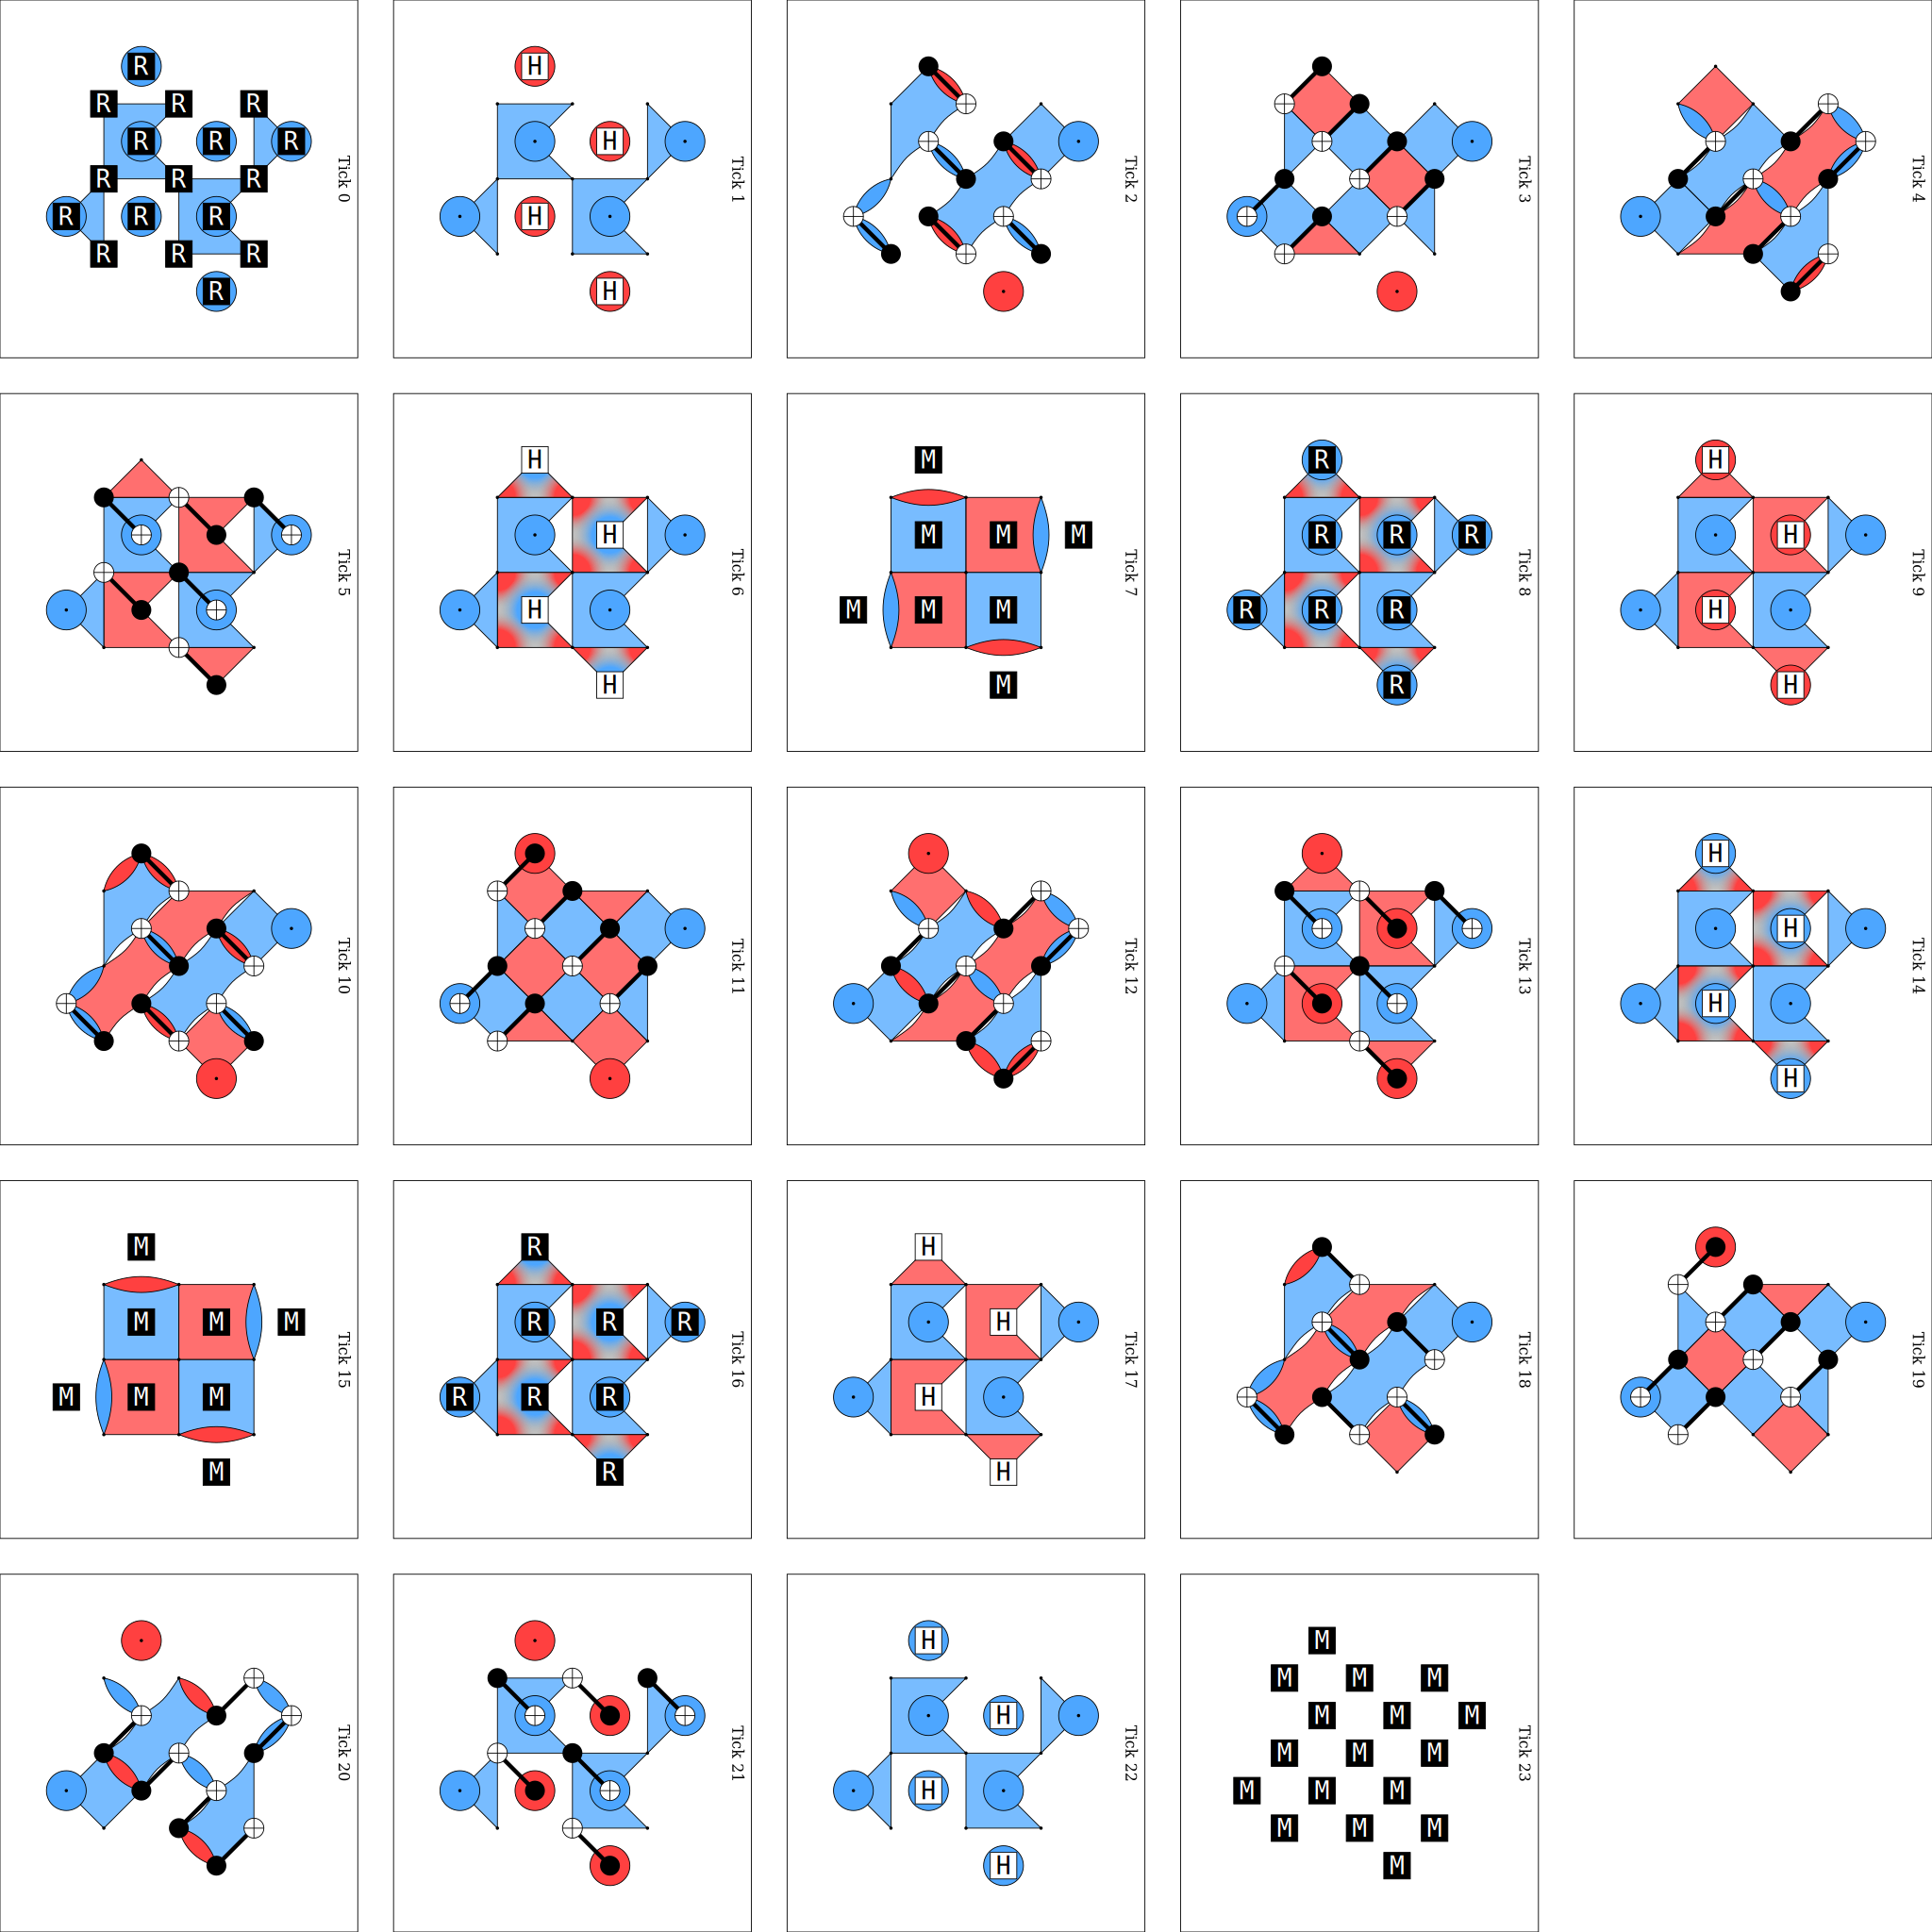

swapped: 24 det, 1 obs


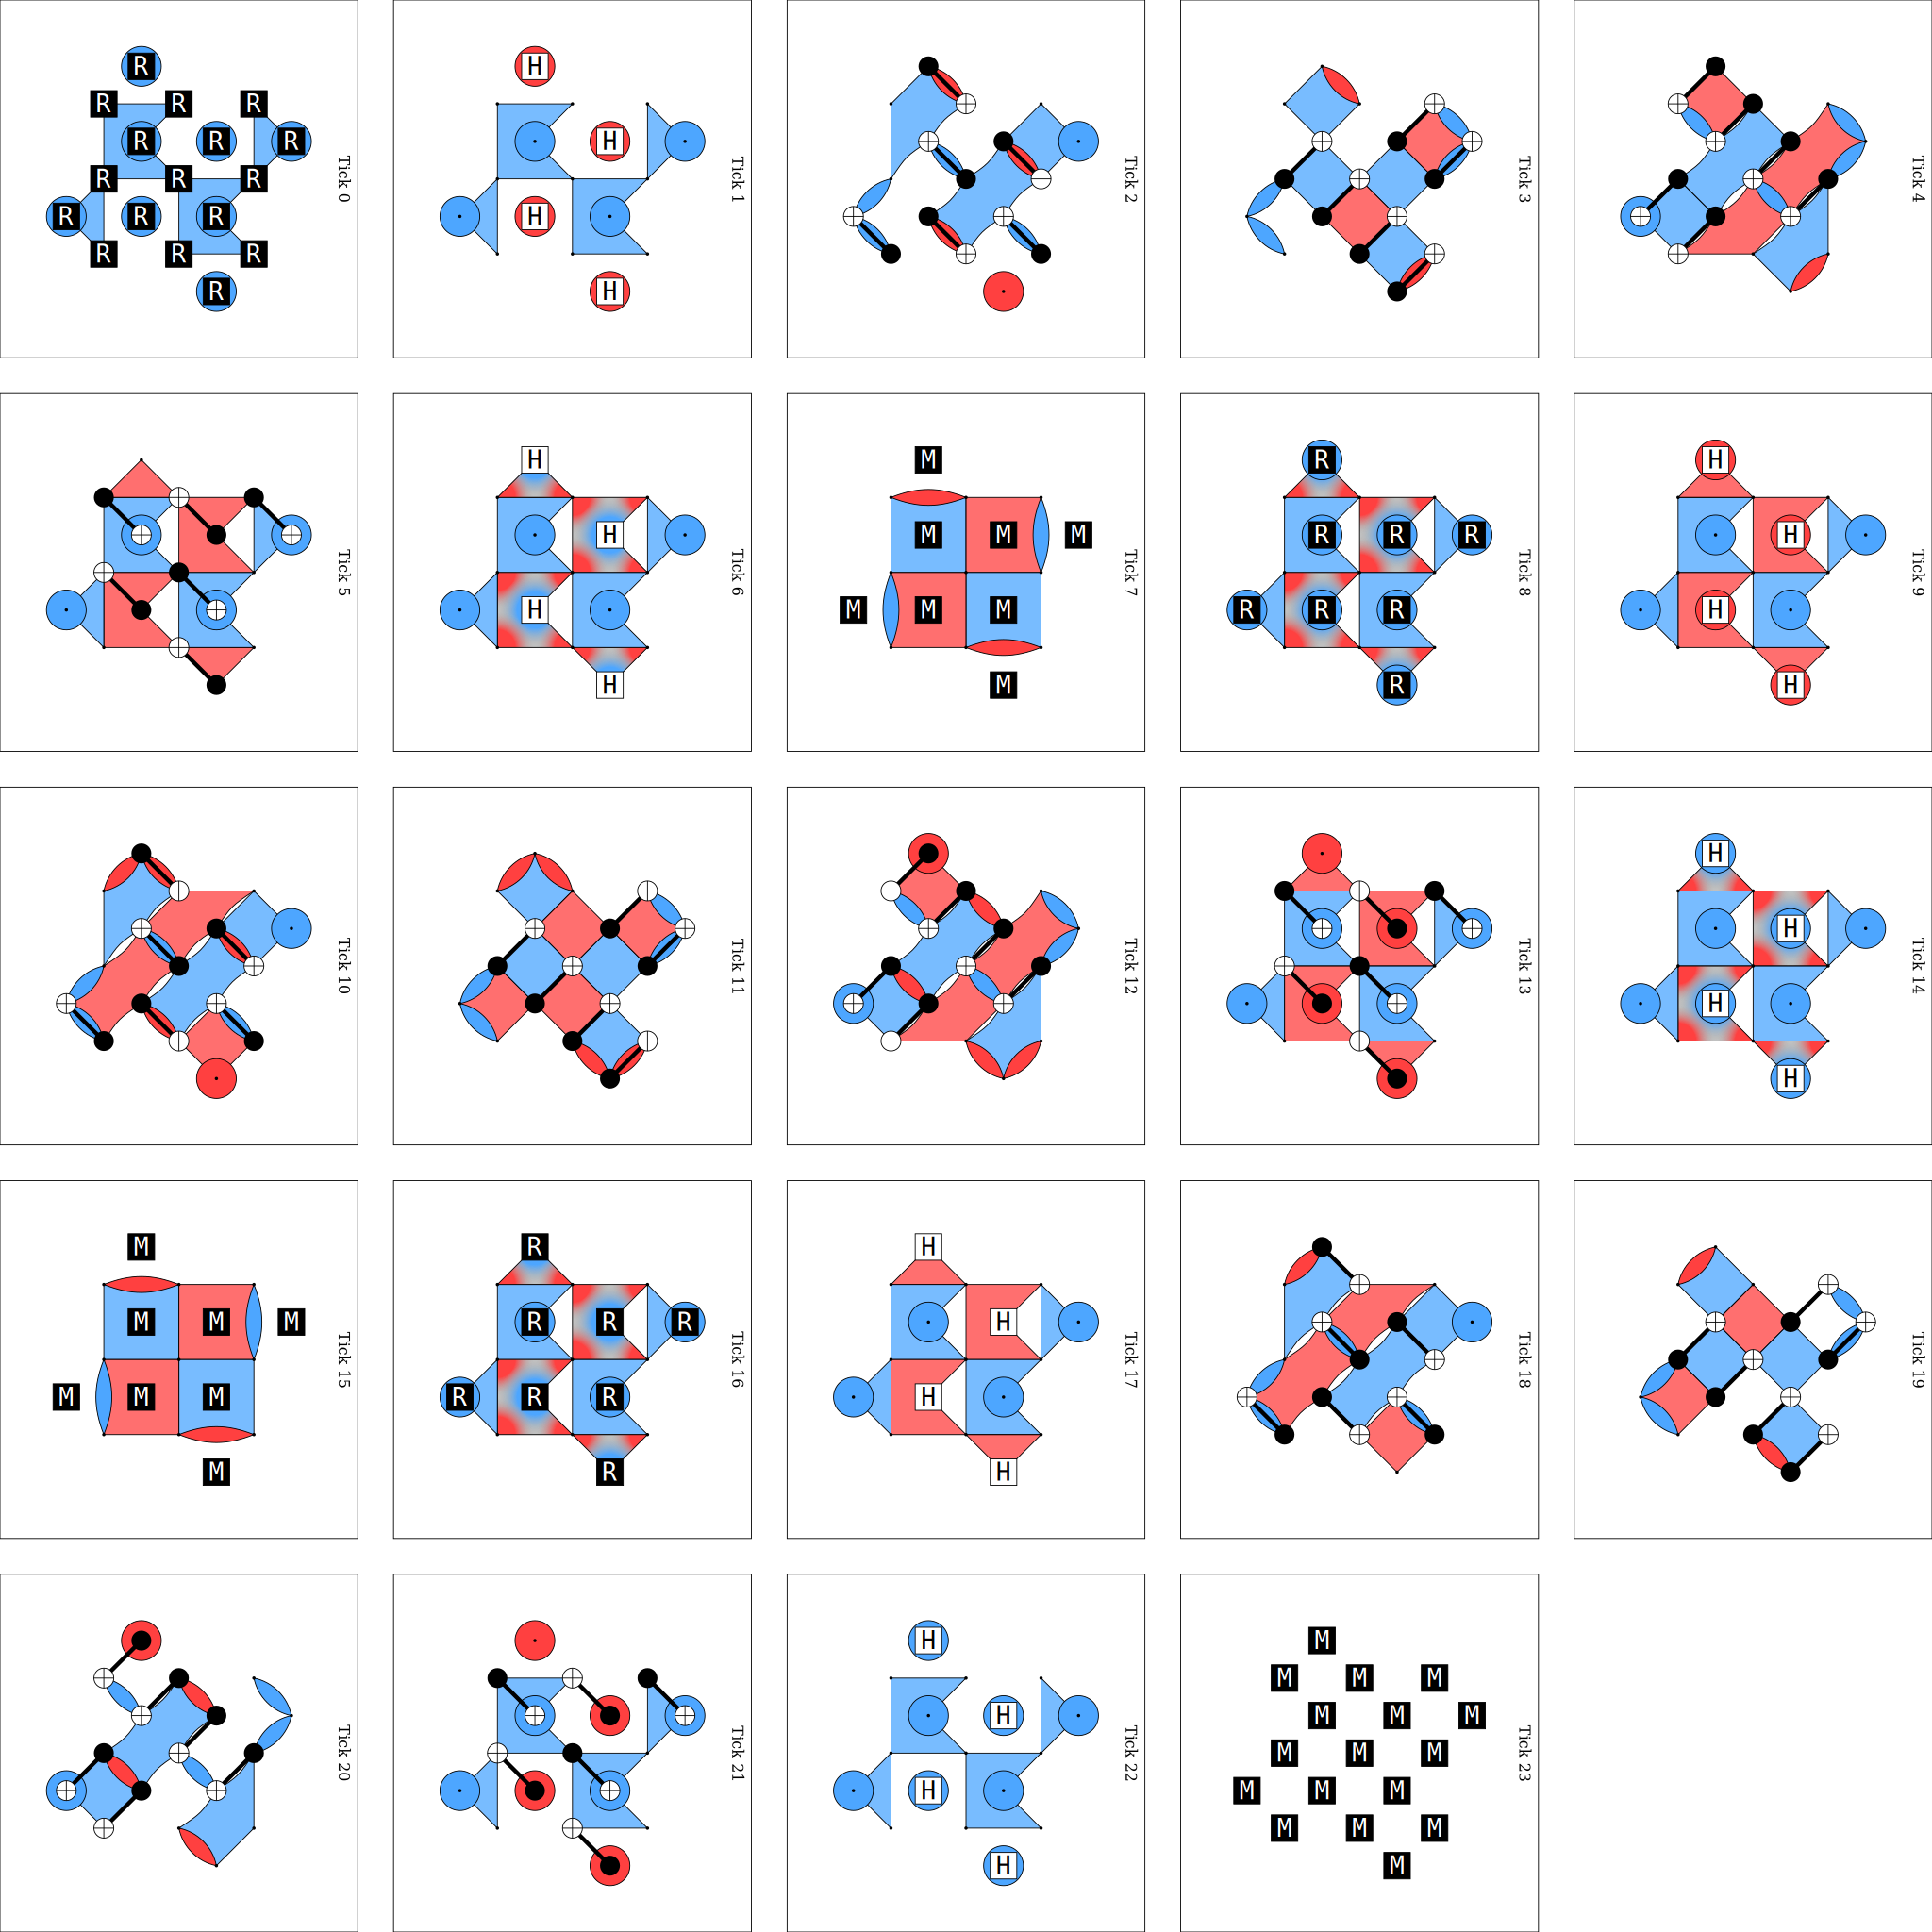

In [2]:
for scheduling in ['perpendicular', 'swapped']:
    system = QECSystem()
    system.add_patch(RotatedSurfaceCode(distance=3), name='patch')
    with contextlib.redirect_stdout(io.StringIO()):
        exp = MemoryExperiment(
            qec_system=system,
            extraction_block_class=RotatedSurfaceCodeExtractionBlock,
            rounds=3, basis='Z',
            se_block_kwargs={'scheduling': scheduling},
        )
        c = exp.build()
    print(f'{scheduling}: {c.num_detectors} det, {c.num_observables} obs')
    display(c.diagram('detslice-with-ops-svg'))

## 2. Noiseless verification

In [3]:
for scheduling in ['perpendicular', 'swapped']:
    for basis in ['Z', 'X']:
        for d in [3, 5, 7]:
            system = QECSystem()
            system.add_patch(RotatedSurfaceCode(distance=d), name='patch')
            with contextlib.redirect_stdout(io.StringIO()):
                exp = MemoryExperiment(
                    qec_system=system,
                    extraction_block_class=RotatedSurfaceCodeExtractionBlock,
                    rounds=d, basis=basis,
                    se_block_kwargs={'scheduling': scheduling},
                )
                c = exp.build()
            det, obs = c.compile_detector_sampler().sample(shots=200, separate_observables=True)
            print(f'  {scheduling:12s}  basis={basis}  d={d}  clean={not det.any() and not obs.any()}')

  perpendicular  basis=Z  d=3  clean=True
  perpendicular  basis=Z  d=5  clean=True
  perpendicular  basis=Z  d=7  clean=True
  perpendicular  basis=X  d=3  clean=True
  perpendicular  basis=X  d=5  clean=True
  perpendicular  basis=X  d=7  clean=True
  swapped       basis=Z  d=3  clean=True
  swapped       basis=Z  d=5  clean=True
  swapped       basis=Z  d=7  clean=True
  swapped       basis=X  d=3  clean=True
  swapped       basis=X  d=5  clean=True
  swapped       basis=X  d=7  clean=True


## 3. LER comparison — d=5,7, p=1e-3

Expected: `swapped` LER >> `perpendicular` LER for both Z and X memory.

In [ ]:
from itertools import product as iproduct

p = 1e-3
noise = NoiseConfig(p_meas=p, p_reset=p, p_1q=p, p_2q=p, p_idle=p)

tasks = []
for scheduling, basis, d in iproduct(['perpendicular', 'swapped'], ['Z', 'X'], [5, 7]):
    system = QECSystem()
    system.add_patch(RotatedSurfaceCode(distance=d), name='patch')
    with contextlib.redirect_stdout(io.StringIO()):
        exp = MemoryExperiment(
            qec_system=system,
            extraction_block_class=RotatedSurfaceCodeExtractionBlock,
            rounds=d, basis=basis, noise_params=noise,
            se_block_kwargs={'scheduling': scheduling},
        )
        c = exp.build()
    tasks.append(ExperimentTask(c, json_metadata={
        'scheduling': scheduling, 'basis': basis, 'd': d, 'p': p,
    }))

print(f'Built {len(tasks)} tasks')

pipeline = SimulationPipeline(
    decoder_config=DecoderConfig('nv-qldpc-decoder', backend='gpu'),
    max_errors=30, max_shots=1_000_000_000, num_workers=1, print_progress=True,
)
df = pipeline.run_batch(tasks)
df[['scheduling', 'basis', 'd', 'p', 'shots', 'errors', 'logical_error_rate']]

Built 8 tasks
Task 1/8: {'scheduling': 'perpendicular', 'basis': 'Z', 'd': 5, 'p': 0.001}
shots=10,000 kept=10,000 errors=1 LER=1.00e-04 elapsed=6.0s ETA=2m54s
shots=20,000 kept=20,000 errors=3 LER=1.50e-04 elapsed=7.2s ETA=1m04s
shots=30,000 kept=30,000 errors=4 LER=1.33e-04 elapsed=8.4s ETA=55s
shots=40,000 kept=40,000 errors=4 LER=1.00e-04 elapsed=9.6s ETA=1m02s
shots=50,000 kept=50,000 errors=7 LER=1.40e-04 elapsed=10.8s ETA=35s
shots=60,000 kept=60,000 errors=8 LER=1.33e-04 elapsed=12.0s ETA=33s
shots=70,000 kept=70,000 errors=8 LER=1.14e-04 elapsed=13.2s ETA=36s
shots=80,000 kept=80,000 errors=8 LER=1.00e-04 elapsed=14.4s ETA=39s
shots=90,000 kept=90,000 errors=9 LER=1.00e-04 elapsed=15.6s ETA=36s
shots=100,000 kept=100,000 errors=12 LER=1.20e-04 elapsed=16.7s ETA=25s
shots=110,000 kept=110,000 errors=14 LER=1.27e-04 elapsed=17.9s ETA=20s
shots=120,000 kept=120,000 errors=15 LER=1.25e-04 elapsed=19.1s ETA=19s
shots=130,000 kept=130,000 errors=17 LER=1.31e-04 elapsed=20.3s ETA=16s

,scheduling,basis,d,p,shots,errors,logical_error_rate
0,perpendicular,Z,5,0.001,240000,35,0.000146
1,perpendicular,Z,7,0.001,890000,30,0.000034
2,perpendicular,X,5,0.001,150000,31,0.000207
3,perpendicular,X,7,0.001,870000,30,0.000034
4,swapped,Z,5,0.001,70000,32,0.000457
5,swapped,Z,7,0.001,160000,30,0.000188
6,swapped,X,5,0.001,40000,31,0.000775
7,swapped,X,7,0.001,210000,30,0.000143


: 